### Step 1: Setup Paths and Load the Aggregated Dataset
Resolves an `../eda_plots/` output directory (created on first run), loads `step4_patient_aggregated.xlsx` (1 row per patient), and sets the seaborn style used by every plot below. All subsequent cells write their PNG outputs to the same directory.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import pi
from sklearn.preprocessing import MinMaxScaler

# 1. SETUP OUTPUT PATH
# We use the raw string (r"...") to handle Windows paths correctly
target_dir = os.path.join(os.path.dirname(os.getcwd()), "eda_plots")

# Create directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f" Created output directory: {target_dir}")
else:
    print(f"  Output directory exists: {target_dir}")

# 2. LOAD DATA
# Adjust this path if your Excel file is in a different location relative to the notebook
input_path = os.path.join(os.path.dirname(os.getcwd()), "csv", "step4_patient_aggregated.xlsx")

if os.path.exists(input_path):
    df = pd.read_excel(input_path)
    print(f" Loaded Dataset: {len(df)} patients")
else:
    # Fallback to checking local directory
    try:
        df = pd.read_excel('step4_patient_aggregated.xlsx')
        print(" Loaded data from local folder.")
    except:
        print(" Error: Could not find dataset. Please check the path.")

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

ℹ️  Output directory exists: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots
✅ Loaded Dataset: 62135 patients


### Step 2: Univariate — Numerical Distributions
Histograms for the six numeric features (`AGE`, `Index_LOS`, `Num_Visits`, `Num_Admissions`, `Total_Meds_Count`, `Total_Unique_Diagnoses`) to sanity-check the shape of each distribution before any modelling. Saved as `univariate_numerical.png`.

--- Generating 1/7: Numerical Distributions ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\univariate_numerical.png


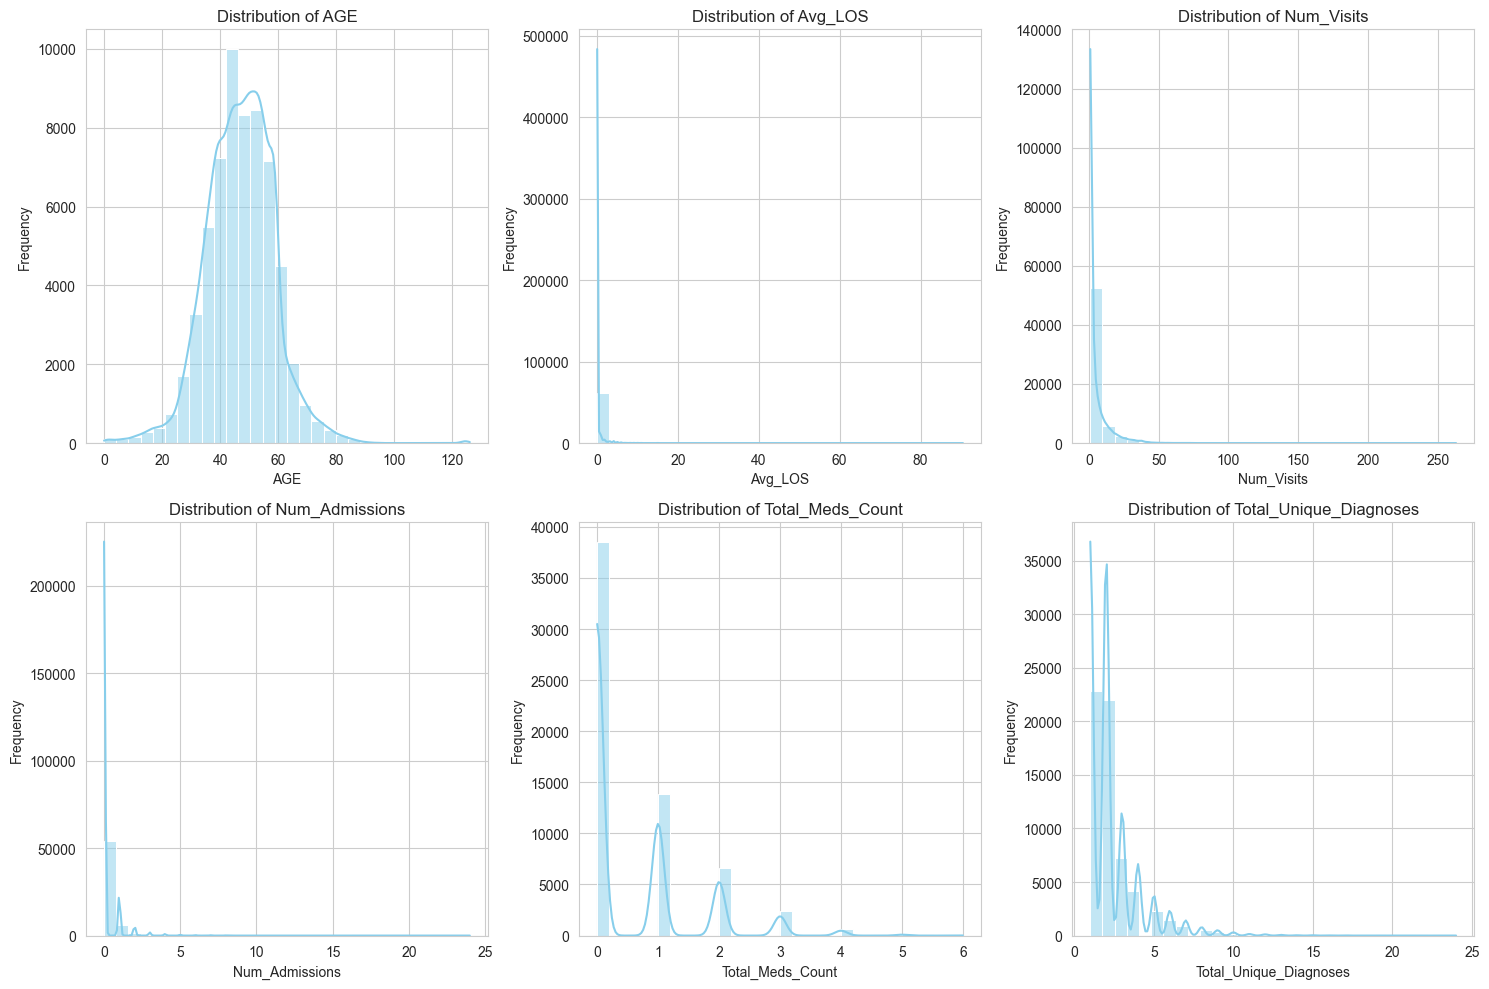

In [21]:
# 2. UNIVARIATE: NUMERICAL DISTRIBUTIONS
print("--- Generating 1/7: Numerical Distributions ---")

num_cols = ['AGE', 'Index_LOS', 'Num_Visits', 'Num_Admissions', 'Total_Meds_Count', 'Total_Unique_Diagnoses']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()

# Save & Show
save_path = os.path.join(target_dir, 'univariate_numerical.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

### Step 3: Univariate — Categorical Counts
Bar counts for the five categorical / binary fields (`SEX`, `Readmitted_Yes_No`, `Admitted_Yes_No`, `Complication_Yes_No`, `SEVERITY_INDEX`) to visualise class balance. The admission / readmission bars make the 1:6.77 and 1:2.59 class imbalance obvious — this informs the `scale_pos_weight` / `class_weight='balanced'` choices in the ML notebooks.

--- Generating 2/7: Categorical Counts ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\univariate_categorical.png


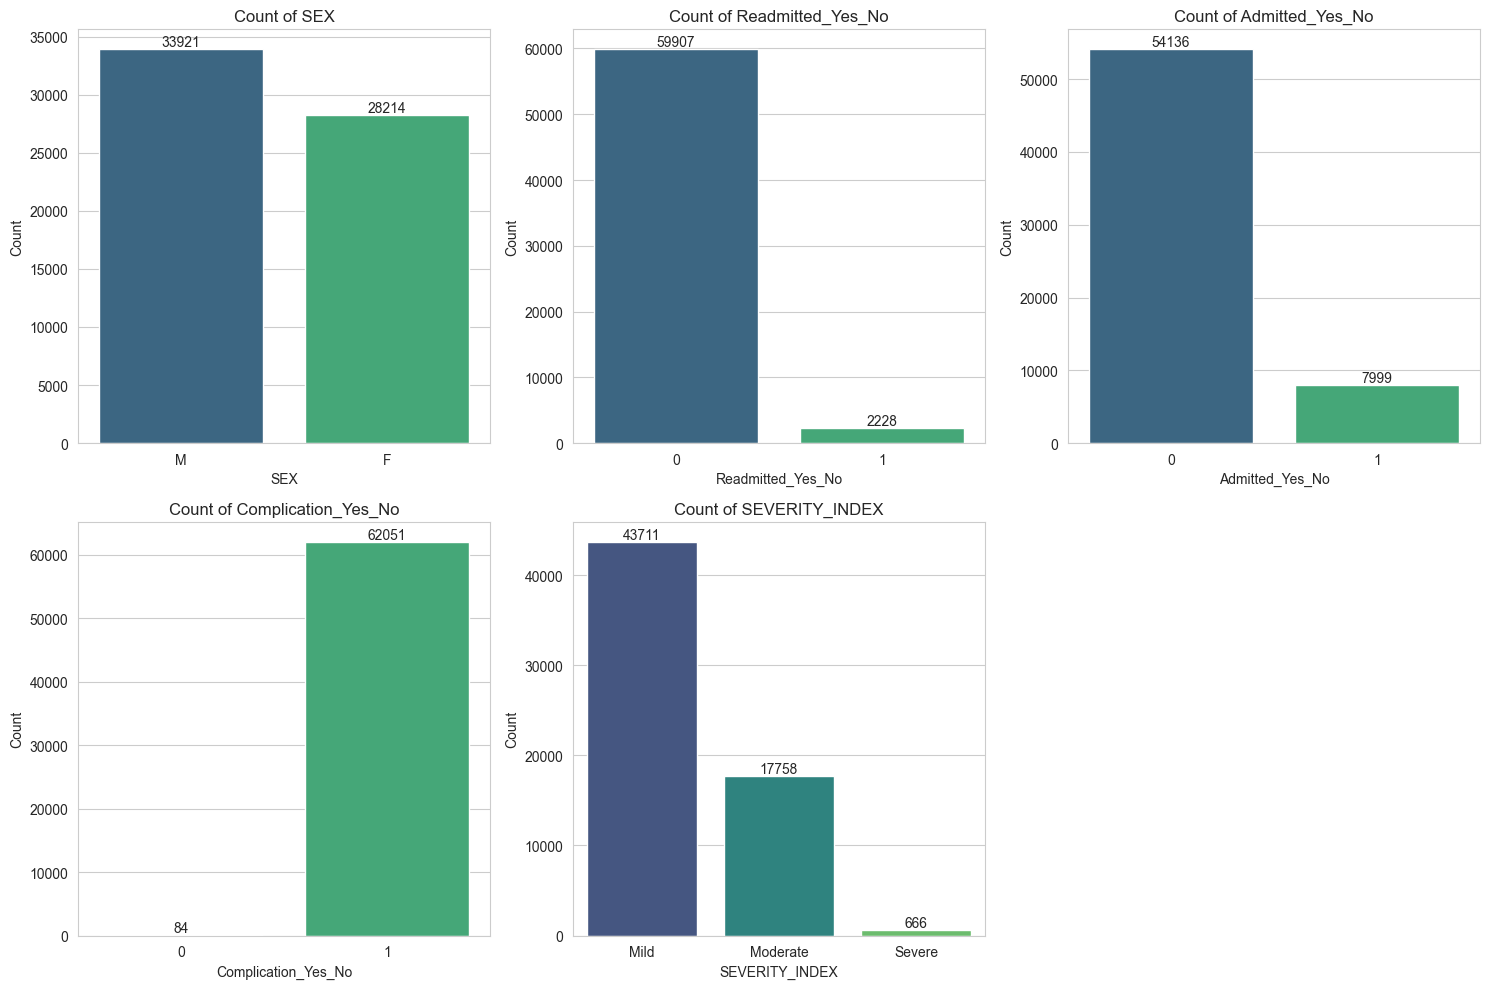

In [22]:
# 3. UNIVARIATE: CATEGORICAL COUNTS
print("--- Generating 2/7: Categorical Counts ---")

cat_cols = ['SEX', 'Readmitted_Yes_No', 'Admitted_Yes_No', 'Complication_Yes_No', 'SEVERITY_INDEX']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    counts = df[col].value_counts()
    
    # Plot with hue fix to avoid FutureWarnings
    sns.barplot(x=counts.index, y=counts.values, palette="viridis", hue=counts.index, legend=False)
    plt.title(f'Count of {col}')
    plt.ylabel('Count')
    
    # Add labels
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()

# Save & Show
save_path = os.path.join(target_dir, 'univariate_categorical.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

### Step 4: Bivariate — Numeric Features by Readmission Status
Boxplots splitting every numeric feature by `Readmitted_Yes_No`. Features where the two boxes separate cleanly (e.g. `Num_Visits`, `Index_LOS`, `Total_Unique_Diagnoses`) are the ones we expect to carry signal for Track B.

--- Generating 3/7: Readmission Boxplots ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\bivariate_readmission_num.png


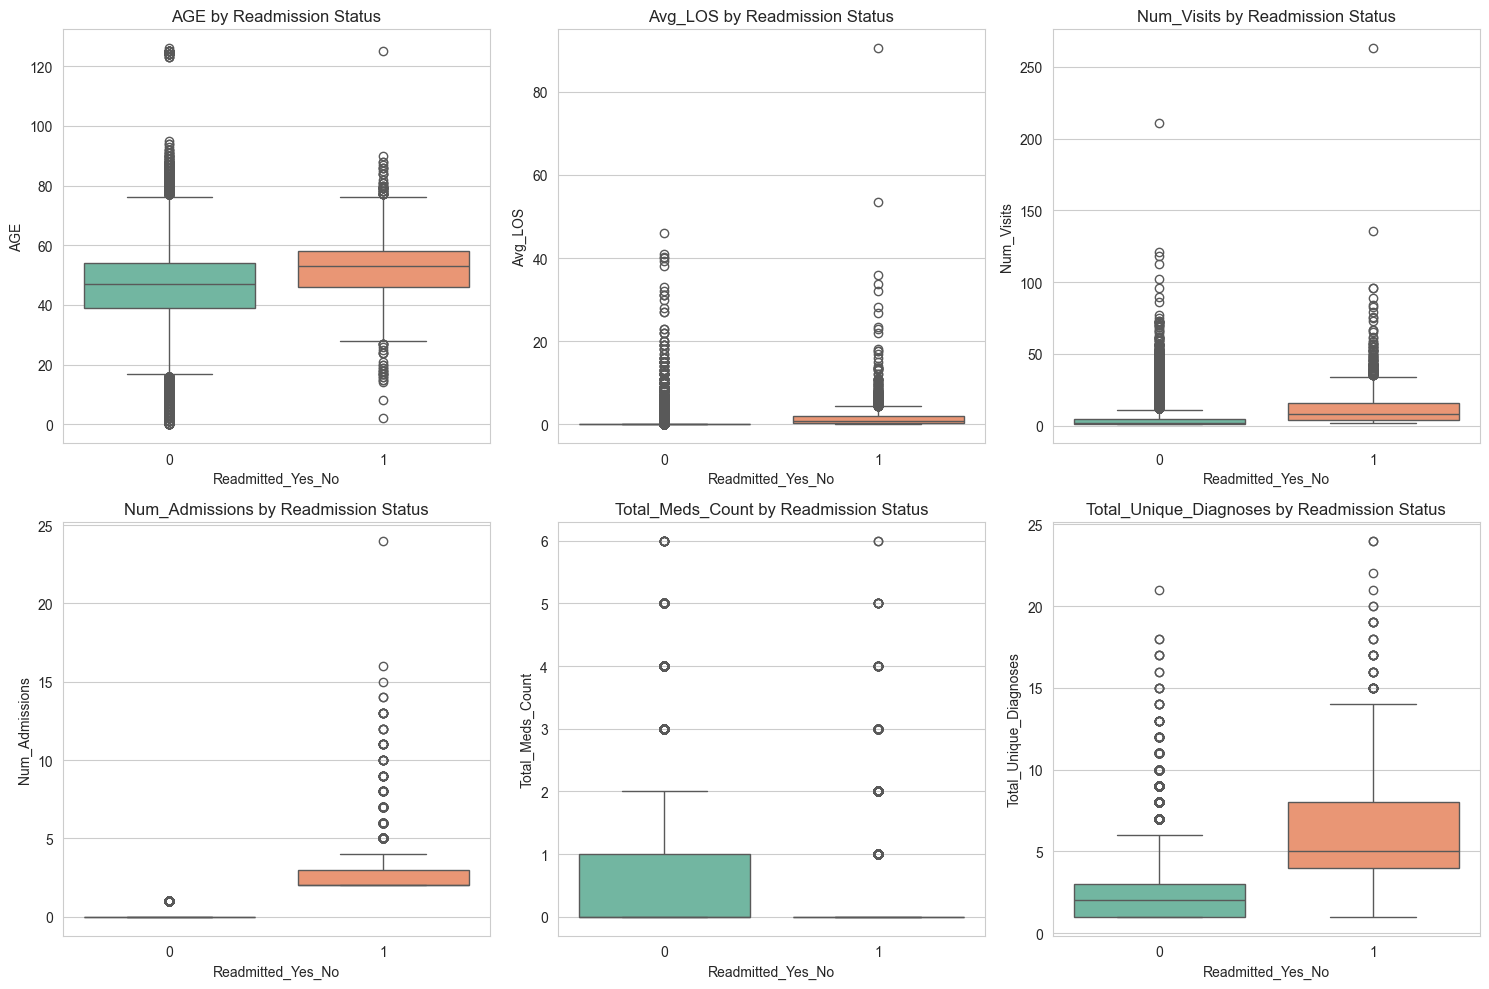

In [23]:
# 4. BIVARIATE: READMISSION ANALYSIS
print("--- Generating 3/7: Readmission Boxplots ---")

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    # Boxplot with hue fix
    sns.boxplot(x='Readmitted_Yes_No', y=col, data=df, palette="Set2", hue='Readmitted_Yes_No', legend=False)
    plt.title(f'{col} by Readmission Status')

plt.tight_layout()

# Save & Show
save_path = os.path.join(target_dir, 'bivariate_readmission_num.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

### Step 5: Bivariate — Numeric Features by Severity Index
Boxplots splitting every numeric feature by the three-level `SEVERITY_INDEX` (Mild / Moderate / Severe). Confirms that severity ordering behaves sensibly: severe patients have more meds, more visits, and a longer average LOS than mild ones.

--- Generating 4/7: Severity Boxplots ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\bivariate_severity_num.png


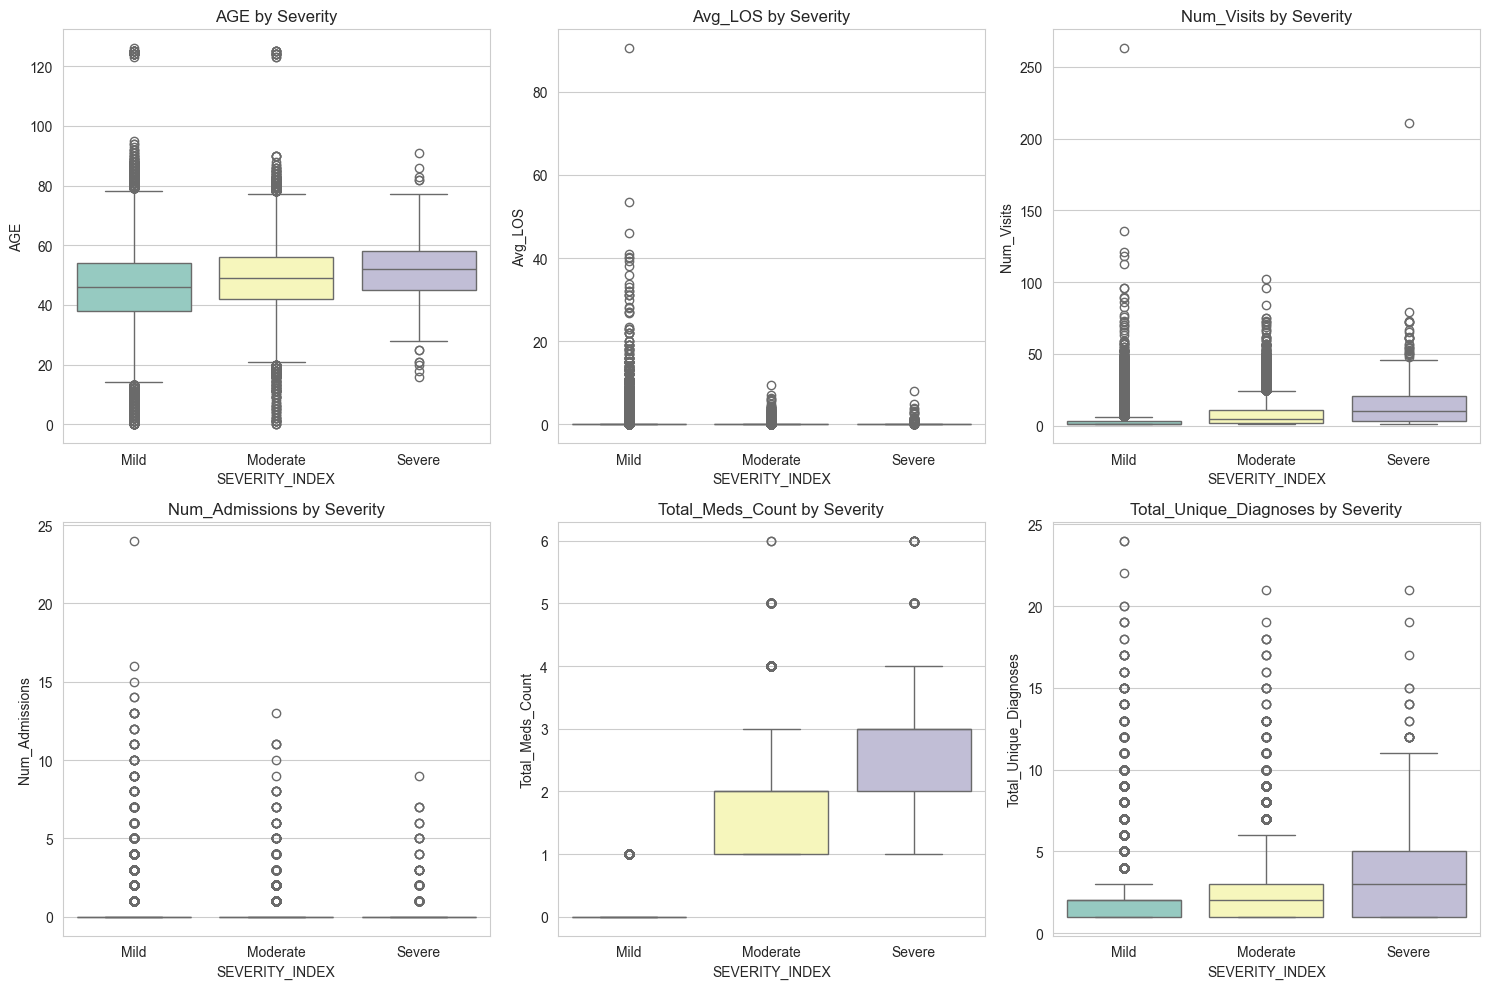

In [24]:
# 5. BIVARIATE: SEVERITY ANALYSIS
print("--- Generating 4/7: Severity Boxplots ---")

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    # Boxplot with hue fix and specific order
    sns.boxplot(x='SEVERITY_INDEX', y=col, data=df, 
                order=['Mild', 'Moderate', 'Severe'], 
                palette="Set3", hue='SEVERITY_INDEX', legend=False)
    plt.title(f'{col} by Severity')

plt.tight_layout()

# Save & Show
save_path = os.path.join(target_dir, 'bivariate_severity_num.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

### Step 6: Multivariate — Correlation Heatmap
Pearson correlation matrix across the numeric features plus the binary targets, used to spot obvious multicollinearity (e.g. `Num_Visits` with `Num_Admissions`) and to eyeball which raw features already correlate with admission / readmission.

--- Generating 5/7: Correlation Heatmap ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\multivariate_correlation.png


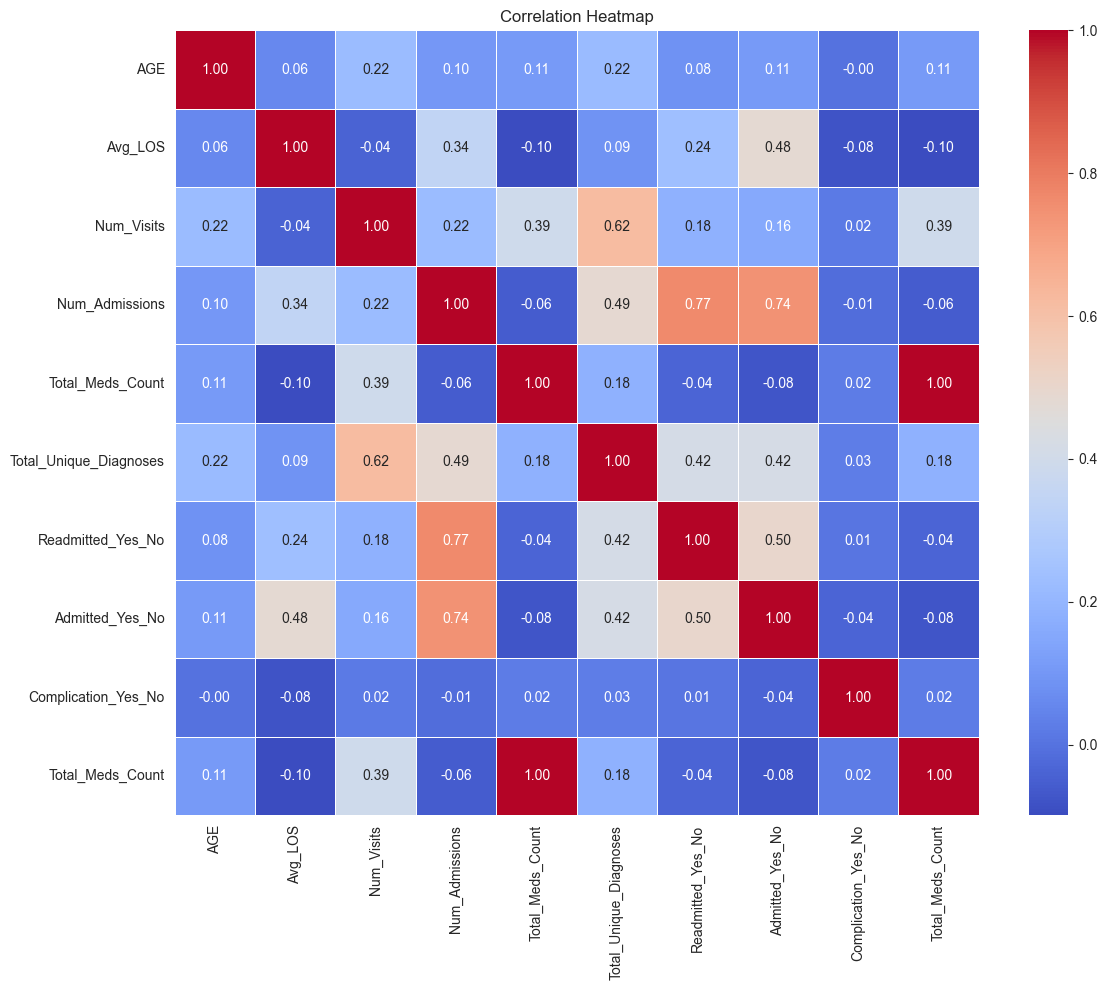

In [25]:
# 6. MULTIVARIATE: CORRELATION HEATMAP
print("--- Generating 5/7: Correlation Heatmap ---")

# Select columns for correlation
corr_cols = num_cols + ['Readmitted_Yes_No', 'Admitted_Yes_No', 'Complication_Yes_No', 'Total_Meds_Count']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()

# Save & Show
save_path = os.path.join(target_dir, 'multivariate_correlation.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

### Step 7: Complications and Severity Deep Dive
Two plots:
- **Plot A** — readmission rate by complication type, to see which `COMP_*` flags carry the strongest readmission signal.
- **Plot B** — stacked bar of readmission proportion by severity level, showing how readmission probability climbs from Mild → Moderate → Severe.

--- Generating 6/7: Complications & Severity Plots ---
💾 Saved Plot A: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\bivariate_complications_readmission.png


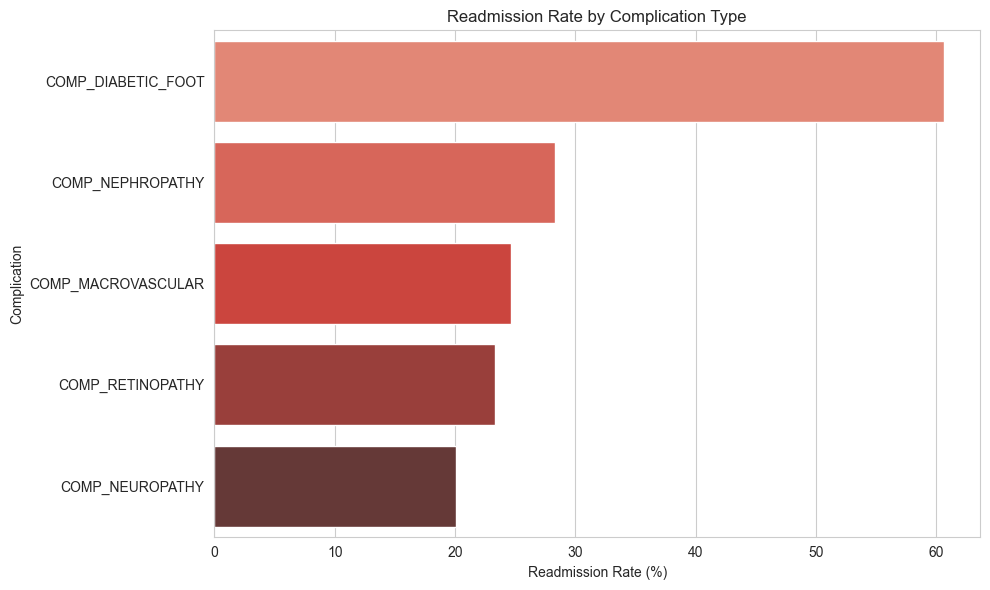

💾 Saved Plot B: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\bivariate_severity_readmission.png


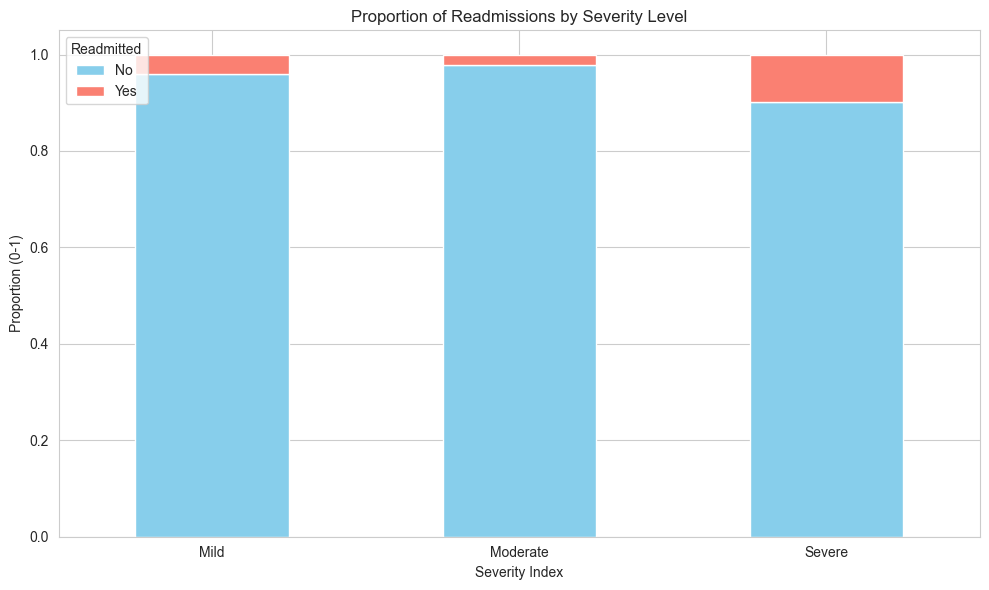

In [26]:
# 7. COMPLICATIONS & SEVERITY DEEP DIVE
print("--- Generating 6/7: Complications & Severity Plots ---")

# --- PLOT A: Complications Readmission Rate ---
comp_cols = [c for c in df.columns if c.startswith('COMP_')]
comp_data = []

for col in comp_cols:
    rate = df[df[col] == 1]['Readmitted_Yes_No'].mean() * 100
    comp_data.append({'Complication': col, 'Readmission_Rate (%)': rate})

comp_df = pd.DataFrame(comp_data).sort_values(by='Readmission_Rate (%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Readmission_Rate (%)', y='Complication', data=comp_df, palette="Reds_d", hue='Complication', legend=False)
plt.title('Readmission Rate by Complication Type')
plt.xlabel('Readmission Rate (%)')
plt.tight_layout()

# Save Plot A
save_path_a = os.path.join(target_dir, 'bivariate_complications_readmission.png')
plt.savefig(save_path_a)
print(f"💾 Saved Plot A: {save_path_a}")
plt.show()

# --- PLOT B: Severity Stacked Bar ---
severity_readmit = pd.crosstab(df['SEVERITY_INDEX'], df['Readmitted_Yes_No'], normalize='index')

ax = severity_readmit.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Proportion of Readmissions by Severity Level')
plt.ylabel('Proportion (0-1)')
plt.xlabel('Severity Index')
plt.legend(title='Readmitted', labels=['No', 'Yes'], loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

# Save Plot B
save_path_b = os.path.join(target_dir, 'bivariate_severity_readmission.png')
plt.savefig(save_path_b)
print(f"💾 Saved Plot B: {save_path_b}")
plt.show()

### Step 8: Advanced — Readmitted vs Not-Readmitted Radar Chart
Min-max scales the five most discriminative numeric features and overlays two polar profiles: readmitted (crimson) and not-readmitted (sky blue). The area difference visualises the multi-variable gap between the two cohorts, which is why Track B is learnable at AUC ≈ 0.88.

--- Generating 7/7: Radar Chart ---
💾 Saved: C:\Users\thiranbarath\Documents\GitHub\dataPreprocessing\eda_plots\advanced_radar_chart.png


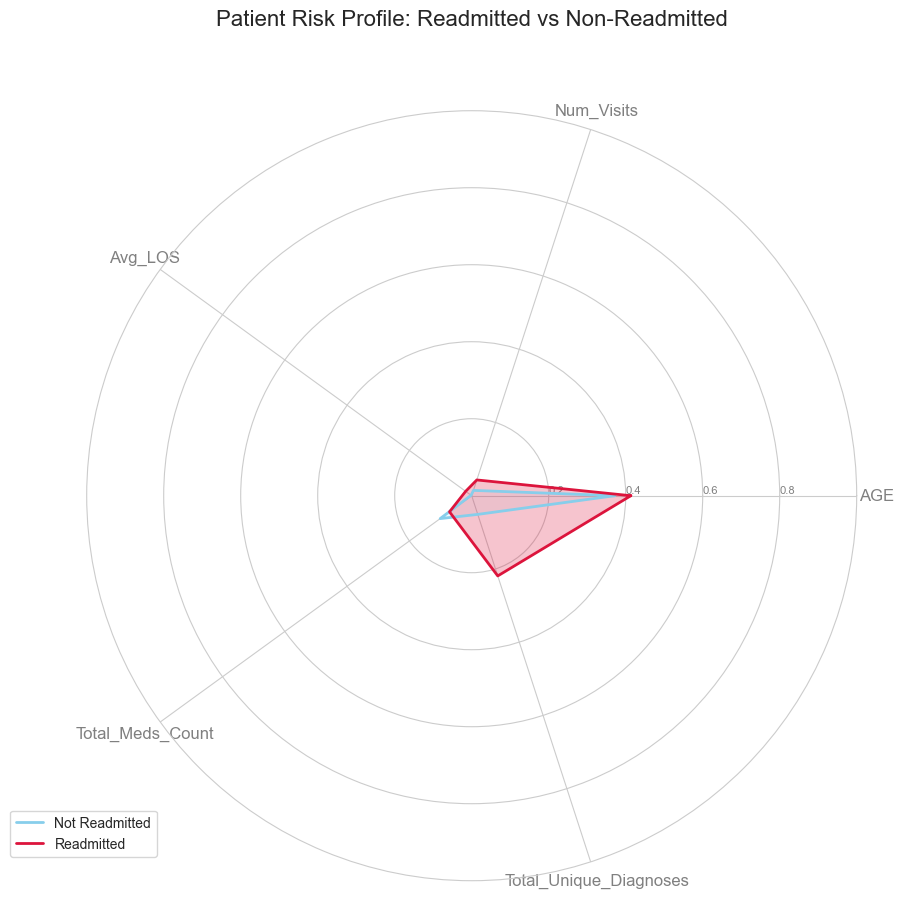

------------------------------
🎉 All EDA plots have been generated and saved successfully!


In [27]:
# 8. ADVANCED: RADAR CHART
print("--- Generating 7/7: Radar Chart ---")

# Prepare Data
features = ['AGE', 'Num_Visits', 'Index_LOS', 'Total_Meds_Count', 'Total_Unique_Diagnoses']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])
profiles = df_scaled.groupby('Readmitted_Yes_No')[features].mean().reset_index()

# Prepare Plot Angles
categories = features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Initialize Plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
plt.ylim(0, 1)

# Plot Not Readmitted (Blue)
values_0 = profiles.loc[0].drop('Readmitted_Yes_No').values.flatten().tolist()
values_0 += values_0[:1]
ax.plot(angles, values_0, linewidth=2, linestyle='solid', label="Not Readmitted", color="skyblue")
ax.fill(angles, values_0, 'skyblue', alpha=0.1)

# Plot Readmitted (Red)
values_1 = profiles.loc[1].drop('Readmitted_Yes_No').values.flatten().tolist()
values_1 += values_1[:1]
ax.plot(angles, values_1, linewidth=2, linestyle='solid', label="Readmitted", color="crimson")
ax.fill(angles, values_1, 'crimson', alpha=0.25)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Patient Risk Profile: Readmitted vs Non-Readmitted", size=16, y=1.1)

# Save & Show
save_path = os.path.join(target_dir, 'advanced_radar_chart.png')
plt.savefig(save_path)
print(f"💾 Saved: {save_path}")
plt.show()

print("-" * 30)
print("🎉 All EDA plots have been generated and saved successfully!")